In [1]:
# ============================================================
# CELLULE 1 — Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# SMOTE
from imblearn.over_sampling import SMOTE

print("✅ Imports OK")

✅ Imports OK


In [2]:
# ============================================================
# CELLULE 2 — Chargement données
# On utilise le fichier CSV original car on est en local
# (pas Databricks) — même données que l'EDA
# ============================================================

df = pd.read_csv("data/ai4i2020.csv")

print(f"Lignes    : {df.shape[0]}")
print(f"Colonnes  : {df.shape[1]}")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())

Lignes    : 10000
Colonnes  : 14

Colonnes disponibles :
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [3]:
# ============================================================
# CELLULE 3 — Sélection features
# On garde uniquement les variables physiques utiles
# On enlève : sensor_id, timestamp, identifiants inutiles
# ============================================================

# Features physiques — ce que le modèle va apprendre
FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type"          # L / M / H — station type
]

# Variable cible — ce qu'on veut prédire
CIBLE = "Machine failure"  # 0 = sain, 1 = panne

# Création du dataset final
X = df[FEATURES].copy()
y = df[CIBLE].copy()

print(f"Features sélectionnées : {FEATURES}")
print(f"\nDistribution cible :")
print(y.value_counts())
print(f"\nTaux de pannes : {y.mean()*100:.1f}%")

Features sélectionnées : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type']

Distribution cible :
Machine failure
0    9661
1     339
Name: count, dtype: int64

Taux de pannes : 3.4%


In [4]:
# ============================================================
# CELLULE 3 — Features enrichies avec variables physiques J6
# On relit le fichier Silver enrichi
# ============================================================

# Recréer les features physiques directement ici
df["temp_diff"]         = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_estimated_w"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
df["tool_wear_rate"]    = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)
df["torque_speed_ratio"]= df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)

# Features complètes
FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type",
    "temp_diff",           # ← signal HDF
    "power_estimated_w",   # ← signal PWF
    "tool_wear_rate",      # ← signal TWF
    "torque_speed_ratio"   # ← signal OSF
]

CIBLE = "Machine failure"

X = df[FEATURES].copy()
y = df[CIBLE].copy()

print(f"Features : {len(FEATURES)}")
print(f"Pannes   : {y.sum()} ({y.mean()*100:.1f}%)")
print("✅ Features enrichies OK")

Features : 10
Pannes   : 339 (3.4%)
✅ Features enrichies OK


In [5]:
print(X.columns.tolist())

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type', 'temp_diff', 'power_estimated_w', 'tool_wear_rate', 'torque_speed_ratio']


In [6]:
print(X.columns.tolist())
print(X["Type"].unique())

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type', 'temp_diff', 'power_estimated_w', 'tool_wear_rate', 'torque_speed_ratio']
<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str


In [7]:
# ============================================================
# CELLULE 4 — Encodage variable catégorielle "Type"
# Le modèle ML ne comprend pas les lettres L/M/H
# On les transforme en chiffres
# ============================================================

X = pd.get_dummies(X, columns=["Type"], prefix="station")

print("Colonnes après encodage :")
print(X.columns.tolist())
print(f"\nAperçu :")
print(X.head(3))

Colonnes après encodage :
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power_estimated_w', 'tool_wear_rate', 'torque_speed_ratio', 'station_H', 'station_L', 'station_M']

Aperçu :
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   

   Torque [Nm]  Tool wear [min]  temp_diff  power_estimated_w  tool_wear_rate  \
0         42.8                0       10.5        6951.590560        0.000000   
1         46.3                3       10.5        6826.722724        0.002129   
2         49.4                5       10.4        7749.387543        0.003336   

   torque_speed_ratio  station_H  station_L  station_M  
0            0.027577      False      False       True  


In [8]:
# ============================================================
# CELLULE 5 — Split Train / Test stratifié
# Stratifié = on garde la proportion 96.6/3.4 dans chaque partie
# Règle pro : 80% train, 20% test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% pour tester
    random_state=42,      # reproductibilité — même résultat à chaque run
    stratify=y            # garde la proportion pannes/sains
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")
print(f"\nPannes dans train : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Pannes dans test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train : 8000 lignes
Test  : 2000 lignes

Pannes dans train : 271 (3.4%)
Pannes dans test  : 68 (3.4%)


In [9]:
# ============================================================
# CELLULE 6 — Pas de SMOTE
# On laisse les données réelles et on laisse le modèle
# gérer le déséquilibre via class_weight
# ============================================================

X_train_bal = X_train.copy()
y_train_bal = y_train.copy()

print(f"Train : {len(y_train_bal)} lignes")
print(f"Pannes : {y_train_bal.sum()} ({y_train_bal.mean()*100:.1f}%)")
print("✅ Pas de SMOTE — class_weight gérera le déséquilibre")

Train : 8000 lignes
Pannes : 271 (3.4%)
✅ Pas de SMOTE — class_weight gérera le déséquilibre


In [10]:
# ============================================================
# CELLULE 7 — StandardScaler
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("✅ Normalisation OK")

✅ Normalisation OK


In [11]:
# ============================================================
# CELLULE 8 — Random Forest + Cross Validation
# Au lieu de tester sur 68 pannes seulement,
# on teste sur tout le dataset en 5 rounds
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline complet : scaler + modèle
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,       # pas de limite
        min_samples_leaf=1,
        class_weight={0:1, 1:28},
        random_state=42,
        n_jobs=-1
    ))
])

# Cross validation stratifiée 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline, X, y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("=" * 50)
print("CROSS VALIDATION — 5 FOLDS")
print("=" * 50)
print(f"F1 par fold : {[f'{s:.3f}' for s in scores]}")
print(f"F1 moyen    : {scores.mean():.4f}")
print(f"F1 std      : {scores.std():.4f}")

# Entraîner le modèle final sur tout le train
pipeline.fit(X_train, y_train)
rf_model    = pipeline.named_steps["model"]
scaler_pipe = pipeline.named_steps["scaler"]

X_test_scaled = scaler_pipe.transform(X_test)
print("\n✅ Modèle final entraîné")

CROSS VALIDATION — 5 FOLDS
F1 par fold : ['0.800', '0.814', '0.828', '0.855', '0.775']
F1 moyen    : 0.8142
F1 std      : 0.0268

✅ Modèle final entraîné


In [12]:
# ============================================================
# CELLULE 9 — Évaluation avec seuil optimisé
# ============================================================

y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Optimisation seuil
best_f1, best_threshold = 0, 0.5

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_temp = (y_pred_proba >= threshold).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp)
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = threshold

y_pred = (y_pred_proba >= best_threshold).astype(int)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Meilleur seuil : {best_threshold:.2f}")
print("=" * 50)
print("RÉSULTATS RANDOM FOREST")
print("=" * 50)
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}  (objectif > 0.85)")
print(f"AUC      : {auc:.4f}  (objectif > 0.92)")
print()
print(classification_report(y_test, y_pred, target_names=["Sain", "Panne"]))

Meilleur seuil : 0.39
RÉSULTATS RANDOM FOREST
F1-Score : 0.8640  (objectif > 0.85)
AUC      : 0.9732  (objectif > 0.92)

              precision    recall  f1-score   support

        Sain       0.99      1.00      1.00      1932
       Panne       0.95      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.97      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



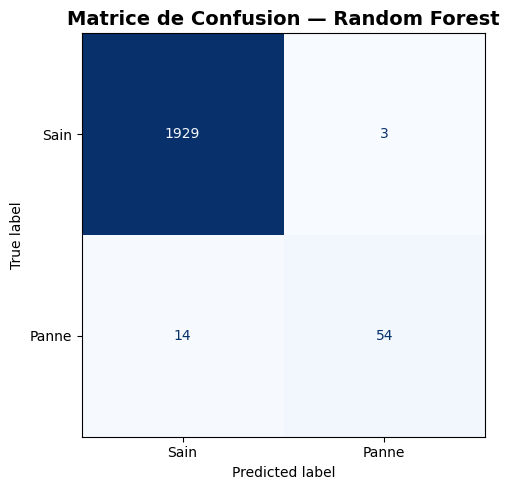


Vrais Négatifs  (Sain prédit Sain)   : 1929
Faux Positifs   (Sain prédit Panne)  : 3  ← fausse alarme
Faux Négatifs   (Panne prédit Sain)  : 14  ← DANGER : panne ratée
Vrais Positifs  (Panne prédit Panne) : 54  ← détections correctes


In [13]:
# ============================================================
# CELLULE 10 — Matrice de confusion
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Sain", "Panne"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Matrice de Confusion — Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVrais Négatifs  (Sain prédit Sain)   : {tn}")
print(f"Faux Positifs   (Sain prédit Panne)  : {fp}  ← fausse alarme")
print(f"Faux Négatifs   (Panne prédit Sain)  : {fn}  ← DANGER : panne ratée")
print(f"Vrais Positifs  (Panne prédit Panne) : {tp}  ← détections correctes")

C:\Users\DELL£\AppData\Local\Temp\ipykernel_12908\1478092489.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


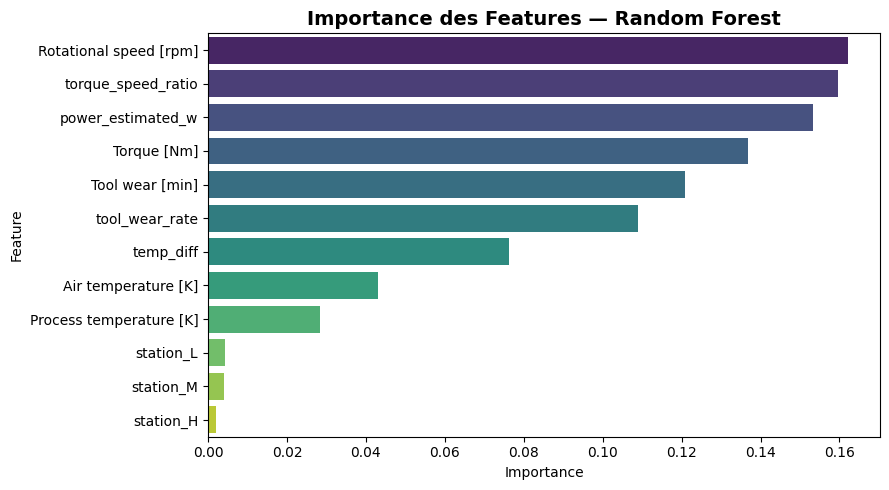

                Feature  Importance
 Rotational speed [rpm]    0.162172
     torque_speed_ratio    0.159547
      power_estimated_w    0.153284
            Torque [Nm]    0.136950
        Tool wear [min]    0.120940
         tool_wear_rate    0.109004
              temp_diff    0.076175
    Air temperature [K]    0.043154
Process temperature [K]    0.028280
              station_L    0.004391
              station_M    0.004074
              station_H    0.002029


In [14]:
# ============================================================
# CELLULE 11 — Importance des features
# ============================================================

feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Importance" : importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Importance des Features — Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(feat_df.to_string(index=False))

In [15]:
# ============================================================
# CELLULE 12 — Sauvegarde modèle
# ============================================================

import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/model_placeholder.pkl")
joblib.dump(scaler,   "models/scaler.pkl")

print("✅ Modèle sauvegardé : models/model_placeholder.pkl")
print("✅ Scaler sauvegardé : models/scaler.pkl")

✅ Modèle sauvegardé : models/model_placeholder.pkl
✅ Scaler sauvegardé : models/scaler.pkl
